# Visualization for SWE-Q relationships in the East and Tuolumne Rivers

Use data-and-plotting environment

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pygeohydro as gh
from pygeohydro import NWIS
import geopandas as gpd
from glob import glob

## 1. Load or download relevant data

### Catchments

In [3]:
basin_shapes = {"tuolumne": "/storage/dlhogan/ess_project_data/domain_Tuolumne_River/shapefiles/catchment/Toulumne_HRUs_GRUs.shp",
                "east" : "/scratch/dlhogan/ess-project-data/domain_East_River_lumped/shapefiles/catchment/East_River_lumped_HRUs_GRUs.shp"}
tuolumne_obj = gpd.read_file(basin_shapes["tuolumne"])
east_obj = gpd.read_file(basin_shapes["east"])

### SWE

In [167]:
# load files
tuolumne_snotels = glob("/scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL/*_cdec_*.csv")
east_snotels = glob("/scratch/dlhogan/ess-project-data/meteorological-data/SNOTEL/*_sntl_*.csv")

# concatentate files for each into dataframes
tuolumne_df = pd.DataFrame()
for f in tuolumne_snotels:
    site_name = f.split("/")[-1].split("_")[0]
    df = pd.read_csv(f)
    df["site"] = site_name
    tuolumne_df = pd.concat([tuolumne_df, df], ignore_index=True, )
east_df = pd.DataFrame()
for f in east_snotels:
    site_name = f.split("/")[-1].split("_")[0]
    df = pd.read_csv(f)
    df["site"] = site_name
    east_df = pd.concat([east_df, df], ignore_index=True)
# set index as datetime and site
tuolumne_df["datetime"] = pd.to_datetime(tuolumne_df["datetime"])
tuolumne_df.set_index(["datetime", "site"], inplace=True)
east_df["datetime"] = pd.to_datetime(east_df["datetime"])
east_df.set_index(["datetime", "site"], inplace=True)


In [11]:
# add column for water year
def water_year(date):
    if date.month >= 10:
        return date.year + 1
    else:
        return date.year
east_df["water_year"] = east_df.index.get_level_values("datetime").map(water_year)
tuolumne_df["water_year"] = tuolumne_df.index.get_level_values("datetime").map(water_year) 

In [100]:
# get peak SWE for each water year and site
tuolumne_peak_swe = tuolumne_df.groupby(["site", "water_year"])["SWE"].max().reset_index()
east_peak_swe = east_df.groupby(["site", "water_year"])["SWE"].max().reset_index()

# drop nan values
tuolumne_peak_swe.dropna(inplace=True)
east_peak_swe.dropna(inplace=True)

# only keep sites with data going back to 1991
tuolumne_peak_swe = tuolumne_peak_swe[tuolumne_peak_swe.water_year >= 1991]
east_peak_swe = east_peak_swe[east_peak_swe.water_year >= 1991]

In [101]:
# get the avearge per year across sites
tuolumne_avg_peak_swe = tuolumne_peak_swe.groupby("water_year")["SWE"].mean().reset_index()
east_avg_peak_swe = east_peak_swe.groupby("water_year")["SWE"].mean().reset_index()

In [102]:
# convert SWE to mm
tuolumne_avg_peak_swe["SWE"] = tuolumne_avg_peak_swe["SWE"] * 25.4
east_avg_peak_swe["SWE"] = east_avg_peak_swe["SWE"] * 25.4

### Streamflow

#### Tuolumne River

In [21]:
tuolmne_bbox = tuolumne_obj.total_bounds

In [104]:
nwis = NWIS()
query = {
    "bBox": ",".join(f"{b:.06f}" for b in tuolmne_bbox),
    "hasDataTypeCd": "dv",
    "outputDataTypeCd": "dv",
}
info_box = nwis.get_info(query)
dates = ("1990-10-01", "2025-09-30")
stations = info_box[
    (info_box.begin_date >= dates[0]) & (info_box.end_date <= dates[1])
].site_no.unique().tolist()

In [110]:
nwis = NWIS()
tuolumne_qobs_ds = nwis.get_streamflow(stations, dates, to_xarray=True, mmd=False)
# convet discharge to mm/day
tuolumne_qobs_ds["discharge"] = tuolumne_qobs_ds["discharge"] * 86400
# divide by area of the basin in m^2 to get mm/day
basin_area_m2 = tuolumne_obj.to_crs("32610").area.sum()
tuolumne_qobs_ds["discharge"] = tuolumne_qobs_ds["discharge"] / basin_area_m2 * 1000

In [186]:
# add water year as a variable
tuolumne_qobs_ds["water_year"] = tuolumne_qobs_ds["time"].dt.year.where(tuolumne_qobs_ds["time"].dt.month < 10, tuolumne_qobs_ds["time"].dt.year + 1)

# groupby water year and get the sum of discharge for the year
tuolumne_qobs_ds_yearly = tuolumne_qobs_ds[["discharge","water_year"]].groupby("water_year").sum().isel(station_id=3)
tuolumne_qobs_ds_amjj = tuolumne_qobs_ds[["discharge","water_year"]].where(tuolumne_qobs_ds["time"].dt.month.isin([4,5,6,7])).groupby("water_year").sum().isel(station_id=3)

# only take values greater than 0
tuolumne_qobs_ds_yearly = tuolumne_qobs_ds_yearly.where(tuolumne_qobs_ds_yearly["discharge"] > 0, drop=True)
tuolumne_qobs_ds_amjj = tuolumne_qobs_ds_amjj.where(tuolumne_qobs_ds_amjj["discharge"] > 0, drop=True)

/home/dlhogan/miniforge3/envs/data-and-plotting/lib/python3.13/site-packages/xarray/structure/concat.py:547: UserWarning: No index created for dimension water_year because variable water_year is not a coordinate. To create an index for water_year, please first call `.set_coords('water_year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/dlhogan/miniforge3/envs/data-and-plotting/lib/python3.13/site-packages/xarray/structure/concat.py:547: UserWarning: No index created for dimension water_year because variable water_year is not a coordinate. To create an index for water_year, please first call `.set_coords('water_year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


#### East River

In [112]:
east_bbox = east_obj.total_bounds

In [113]:
nwis = NWIS()
query = {
    "bBox": ",".join(f"{b:.06f}" for b in east_bbox),
    "hasDataTypeCd": "dv",
    "outputDataTypeCd": "dv",
}
info_box = nwis.get_info(query)
dates = ("1990-10-01", "2025-09-30")
stations = info_box[
    (info_box.begin_date >= dates[0]) & (info_box.end_date <= dates[1])
].site_no.unique().tolist()

In [114]:
east_qobs_ds = nwis.get_streamflow(stations, dates, to_xarray=True, mmd=False)

# convet discharge to mm/day
east_qobs_ds["discharge"] = east_qobs_ds["discharge"] * 86400
# divide by area of the basin in m^2 to get mm/day
basin_area_m2 = east_obj.to_crs(epsg=32613).area.sum()
east_qobs_ds["discharge"] = east_qobs_ds["discharge"] / basin_area_m2 * 1000

In [187]:
# add water year as a variable
east_qobs_ds["water_year"] = east_qobs_ds["time"].dt.year.where(east_qobs_ds["time"].dt.month < 10, east_qobs_ds["time"].dt.year + 1)

# groupby water year and get the sum of discharge for the year
east_qobs_ds_yearly = east_qobs_ds[["discharge","water_year"]].groupby("water_year").sum().isel(station_id=0)
east_qobs_ds_amjj = east_qobs_ds[["discharge","water_year"]].where(east_qobs_ds["time"].dt.month.isin([4,5,6,7])).groupby("water_year").sum().isel(station_id=0)

# only take values greater than 0
east_qobs_ds_yearly = east_qobs_ds_yearly.where(east_qobs_ds_yearly["discharge"] > 0, drop=True)
east_qobs_ds_amjj = east_qobs_ds_amjj.where(east_qobs_ds_amjj["discharge"] > 0, drop=True)

/home/dlhogan/miniforge3/envs/data-and-plotting/lib/python3.13/site-packages/xarray/structure/concat.py:547: UserWarning: No index created for dimension water_year because variable water_year is not a coordinate. To create an index for water_year, please first call `.set_coords('water_year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)
/home/dlhogan/miniforge3/envs/data-and-plotting/lib/python3.13/site-packages/xarray/structure/concat.py:547: UserWarning: No index created for dimension water_year because variable water_year is not a coordinate. To create an index for water_year, please first call `.set_coords('water_year')` on this object.
  ds.expand_dims(dim_name, create_index_for_new_dim=create_index_for_new_dim)


## Plot SWE vs. Q

In [190]:
tuolumne_swe_q = pd.merge(tuolumne_avg_peak_swe, tuolumne_qobs_ds_yearly.to_dataframe(), on="water_year", how="inner")
east_swe_q = pd.merge(east_avg_peak_swe, east_qobs_ds_yearly.to_dataframe(), on="water_year", how="inner")

# convert each to a percent of median
tuolumne_swe_q["SWE"] = tuolumne_swe_q["SWE"] / tuolumne_swe_q["SWE"].median() * 100
tuolumne_swe_q["discharge"] = tuolumne_swe_q["discharge"] / tuolumne_swe_q["discharge"].median() * 100
east_swe_q["SWE"] = east_swe_q["SWE"] / east_swe_q["SWE"].median() * 100
east_swe_q["discharge"] = east_swe_q["discharge"] / east_swe_q["discharge"].median() * 100

# set index to water year
tuolumne_swe_q.set_index("water_year", inplace=True)
east_swe_q.set_index("water_year", inplace=True)

# find the years with the top 3 biggest anomalies in discharge and SWE relationship
tuolumne_swe_q["residuals"] = tuolumne_swe_q["discharge"] - (stats.linregress(tuolumne_swe_q["SWE"], tuolumne_swe_q["discharge"]).slope * tuolumne_swe_q["SWE"] + stats.linregress(tuolumne_swe_q["SWE"], tuolumne_swe_q["discharge"]).intercept)
# top 3 positive and top 3 negative residuals
tuolumne_top_3 = tuolumne_swe_q[tuolumne_swe_q["residuals"] > 0].sort_values(by="residuals", ascending=False).head(3)
tuolumne_bottom_3 = tuolumne_swe_q[tuolumne_swe_q["residuals"] < 0].sort_values(by="residuals", ascending=True).head(3)

east_swe_q["residuals"] = east_swe_q["discharge"] - (stats.linregress(east_swe_q["SWE"], east_swe_q["discharge"]).slope * east_swe_q["SWE"] + stats.linregress(east_swe_q["SWE"], east_swe_q["discharge"]).intercept)
# top 3 positive and top 3 negative residuals
east_top_3 = east_swe_q[east_swe_q["residuals"] > 0].sort_values(by="residuals", ascending=False).head(3)
east_bottom_3 = east_swe_q[east_swe_q["residuals"] < 0].sort_values(by="residuals", ascending=True).head(3)

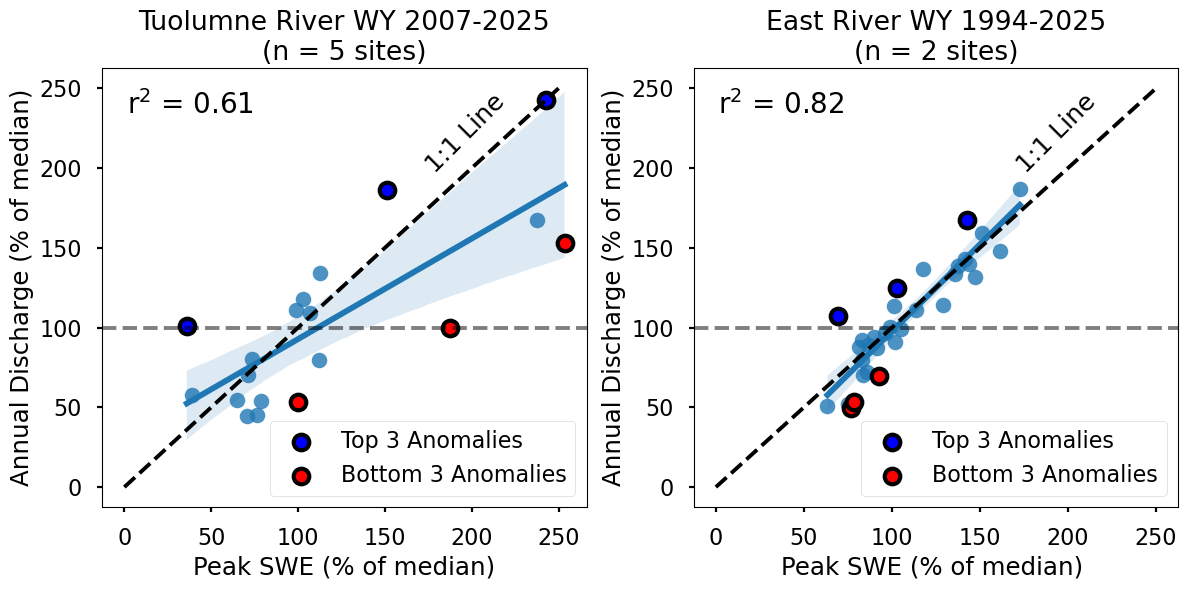

In [191]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
plt.style.use("seaborn-v0_8-poster")
sns.regplot(x=tuolumne_swe_q["SWE"], y=tuolumne_swe_q["discharge"], ax=axs[0])
# add r value to the plot
r, p = stats.pearsonr(tuolumne_swe_q["SWE"], tuolumne_swe_q["discharge"])
axs[0].text(0.05, 0.95, f"r$^2$ = {r**2:.2f}", transform=axs[0].transAxes, verticalalignment="top", fontsize=20)

# sns.regplot(x=east_swe_q["SWE"], y=east_swe_q["discharge"], ax=axs[1])
# plot 1991 to 2005
sns.regplot(x=east_swe_q["SWE"], y=east_swe_q["discharge"], ax=axs[1])
r, p = stats.pearsonr(east_swe_q["SWE"], east_swe_q["discharge"])
axs[1].text(0.05, 0.95, f"r$^2$ = {r**2:.2f}", transform=axs[1].transAxes, verticalalignment="top", fontsize=20)

# mark the top 3 and bottom 3 years on the plot
axs[0].scatter(tuolumne_top_3["SWE"], tuolumne_top_3["discharge"], color="blue", label="Top 3 Anomalies", ec='k', lw=3)
axs[0].scatter(tuolumne_bottom_3["SWE"], tuolumne_bottom_3["discharge"], color="red", label="Bottom 3 Anomalies", ec='k', lw=3)
axs[0].legend()

axs[1].scatter(east_top_3["SWE"], east_top_3["discharge"], color="blue", label="Top 3 Anomalies", ec='k', lw=3)
axs[1].scatter(east_bottom_3["SWE"], east_bottom_3["discharge"], color="red", label="Bottom 3 Anomalies", ec='k', lw=3)
axs[1].legend()

for ax in axs:
    ax.axhline(100, color='k', linestyle='--', alpha=0.5)
    ax.plot([0, 250], [0, 250], "k--")
    # 1:1 line text
    ax.text(0.75, 0.75, "1:1 Line", transform=ax.transAxes, fontsize=18, color="k", alpha=1, rotation=45, ha="center", va="bottom")


axs[0].set_title(f"Tuolumne River WY {tuolumne_swe_q.index.min()}-{tuolumne_swe_q.index.max()}\n(n = {len(tuolumne_snotels)} sites)")
axs[0].set_xlabel("Peak SWE (% of median)")
axs[0].set_ylabel("Annual Discharge (% of median)")

axs[1].set_title(f"East River WY {east_swe_q.index.min()}-{east_swe_q.index.max()}\n(n = {len(east_snotels)} sites)")
axs[1].set_xlabel("Peak SWE (% of median) ")
axs[1].set_ylabel("Annual Discharge (% of median)")
plt.tight_layout()
